In [2]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands

train_info = GraphsTraining()

In [27]:
results_li_pyomo = load_all_pickles("results/study_do/pyomo_do_32_221225", recursive=False)
results_df_pyomo = Results.flatten_convergence_data(results_li_pyomo, key_list=["system", "pretrain", "max_t"], model_type="pyomo")

results_li_pt = load_all_pickles("results/study_do/pytorch_do_400_1000_241225", recursive=False)
results_df_pt = Results.flatten_convergence_data(results_li_pt, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

results_li_jax = load_all_pickles("results/study_do/jax_do_1000_40000_231225", recursive=False)
results_df_jax = Results.flatten_convergence_data(results_li_jax, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

results_li_pt = load_all_pickles("results/study_do/pytorch_do_1000_231225", recursive=False)
results_df_pt_no_pretrain = Results.flatten_convergence_data(results_li_pt, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

results_li_jax = load_all_pickles("results/study_do/jax_do_50000_231225", recursive=False)
results_df_jax_no_pretrain = Results.flatten_convergence_data(results_li_jax, key_list=["system", "pretrain", "max_t"], model_type="pytorch")

Loaded results/study_do/pyomo_do_32_221225/1306942210_2025-12-22_16-30.pkl
Loaded results/study_do/pyomo_do_32_221225/1517729865_2025-12-22_18-15.pkl
Loaded results/study_do/pyomo_do_32_221225/1696042219_2025-12-22_18-58.pkl
Loaded results/study_do/pyomo_do_32_221225/1991204649_2025-12-22_17-10.pkl
Loaded results/study_do/pyomo_do_32_221225/235691498_2025-12-22_16-22.pkl
Loaded results/study_do/pyomo_do_32_221225/2617419430_2025-12-22_19-23.pkl
Loaded results/study_do/pyomo_do_32_221225/2832045152_2025-12-22_20-15.pkl
Loaded results/study_do/pyomo_do_32_221225/292036101_2025-12-22_19-52.pkl
Loaded results/study_do/pyomo_do_32_221225/3074708115_2025-12-22_17-32.pkl
Loaded results/study_do/pyomo_do_32_221225/3516155770_2025-12-22_21-40.pkl
Loaded results/study_do/pyomo_do_32_221225/4138481639_2025-12-22_18-36.pkl
Loaded results/study_do/pyomo_do_32_221225/438281869_2025-12-22_21-13.pkl
Loaded results/study_do/pyomo_do_32_221225/602476258_2025-12-22_16-09.pkl
Loaded results/study_do/pyomo

In [28]:
results_df_pyomo["pretrain"] = False
# results_df_pyomo[["mse_train", "mse_test"]] = results_df_pyomo[["mse_train_coll", "mse_test_coll"]]

In [29]:
comparison_dfs = {
    "pyomo": results_df_pyomo,
    "pytorch": results_df_pt,
    "jax": results_df_jax,
}

comparison_dfs_no_pretrain = {
    "pyomo": results_df_pyomo,
    "pytorch": results_df_pt_no_pretrain,
    "jax": results_df_jax_no_pretrain,
}

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:574: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


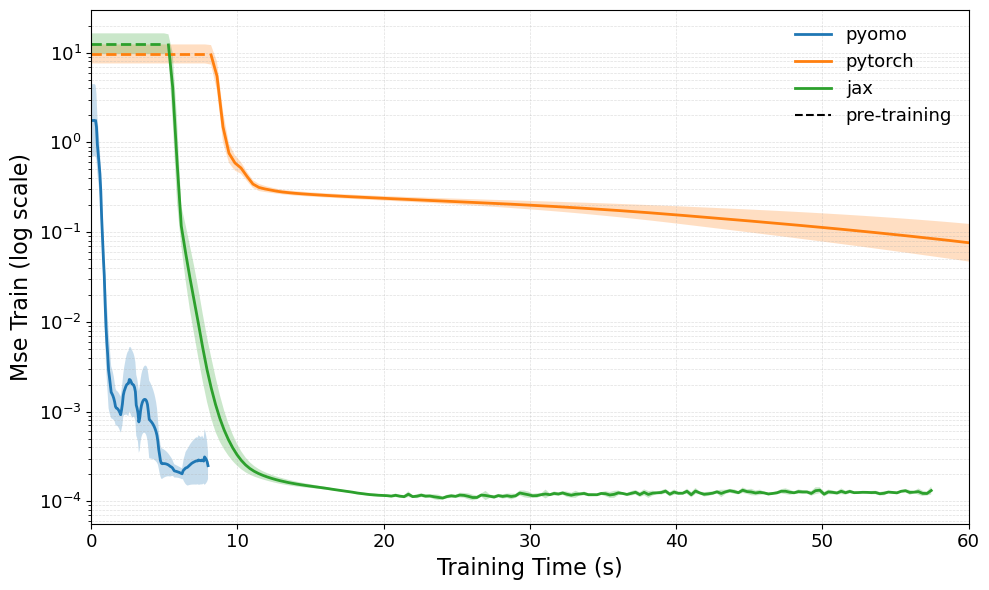

<Axes: xlabel='Training Time (s)', ylabel='Mse Train (log scale)'>

In [33]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_train",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    # tmax_quantile=max_q_maps,
    xlim =(0, 60)
)

/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:574: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


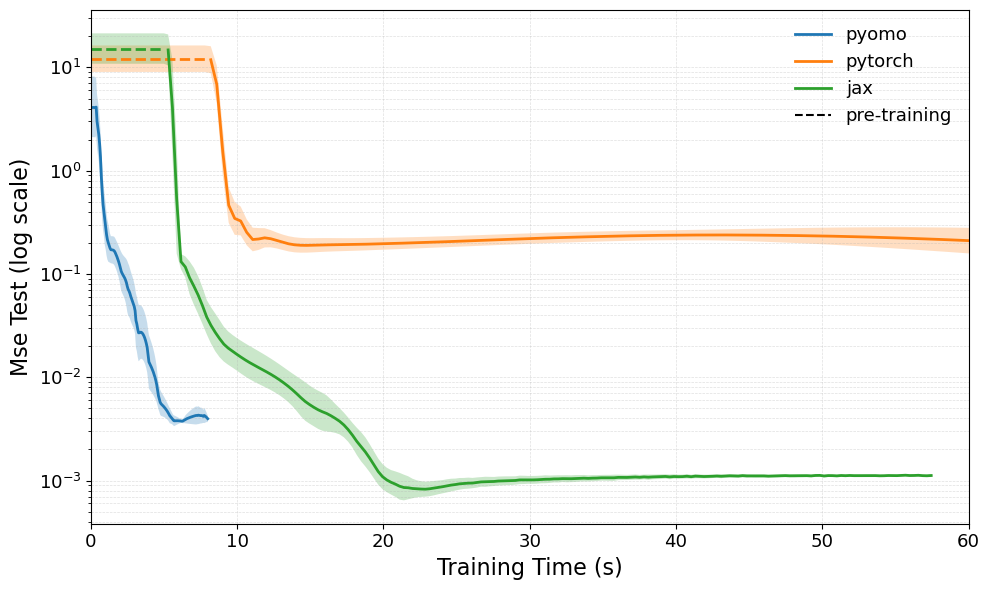

<Axes: xlabel='Training Time (s)', ylabel='Mse Test (log scale)'>

In [34]:
plot_time_bands(
    comparison_dfs,
    y_col="mse_test",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=16,
    tick_fontsize=13,
    legend_fontsize=13,
    title_fontsize=16,
    # tmax_quantile=max_q_maps,
    xlim =(0, 60)
)